<a href="https://colab.research.google.com/github/abhishek18-blog/DataScience-and-ML/blob/main/randomforest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.datasets import make_classification

# Generate a synthetic dataset with exactly 300 rows and 5 features
X, y = make_classification(
    n_samples=300,        # Exactly 300 rows
    n_features=5,         # 5 feature columns
    n_informative=3,      # 3 features are highly predictive
    n_redundant=1,        # 1 feature is redundant (good for Random Forest testing)
    random_state=42,      # Ensures the same data is generated every time
    n_classes=2           # Binary classification (0 or 1)
)

# Create a Pandas DataFrame with custom column names
columns = ['Sensor_A', 'Sensor_B', 'Temperature', 'Humidity', 'Pressure']
df = pd.DataFrame(X, columns=columns)

# Add the target classification column
df['Target_Class'] = y

# Save the dataset to a CSV file
df.to_csv('random_forest_data.csv', index=False)

print("Success! Dataset saved locally as 'random_forest_data.csv' with 300 rows.")

Success! Dataset saved locally as 'random_forest_data.csv' with 300 rows.


Error: 'random_forest_data.csv' not found. Please run the generation script first.
--- Base Model Evaluation Metrics ---
Accuracy:  0.8500
Precision: 0.8800
Recall:    0.7857
F1-Score:  0.8302



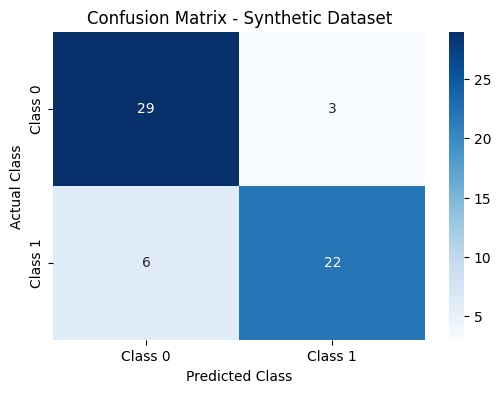

--- Performance Comparison ---
 Number of Trees Max Depth  Accuracy
              10         2  0.750000
              10         5  0.800000
              10        10  0.866667
              10 Unlimited  0.866667
              50         2  0.783333
              50         5  0.816667
              50        10  0.883333
              50 Unlimited  0.883333
             100         2  0.766667
             100         5  0.833333
             100        10  0.850000
             100 Unlimited  0.850000
             200         2  0.766667
             200         5  0.850000
             200        10  0.866667
             200 Unlimited  0.866667


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Load the generated dataset
try:
    df = pd.read_csv('random_forest_data.csv')
except FileNotFoundError:
    print("Error: 'random_forest_data.csv' not found. Please run the generation script first.")
    exit()

# Separate features (X) and target label (y)
X = df.drop('Target_Class', axis=1)
y = df['Target_Class']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train a Base Random Forest Classifier
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)
y_pred = rf_base.predict(X_test)

# 3. Evaluate the Model Metrics
print("--- Base Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}\n")

# 4. Draw the Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix - Synthetic Dataset')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

# 5. Compare Performance by Varying Hyperparameters
print("--- Performance Comparison ---")
# Define the values to test
depths = [2, 5, 10, None] # None allows trees to grow fully
estimators = [10, 50, 100, 200]

results = []

# Loop through all combinations of estimators and depths
for n in estimators:
    for d in depths:
        # Train model with specific hyperparameter combination
        model = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        model.fit(X_train, y_train)

        # Calculate accuracy on the test set
        acc = accuracy_score(y_test, model.predict(X_test))

        # Save results
        results.append({
            'Number of Trees': n,
            'Max Depth': d if d is not None else 'Unlimited',
            'Accuracy': acc
        })

# Display the comparison cleanly in a DataFrame format
comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))